<a href="https://colab.research.google.com/github/urazovandriy-dotcom/ML_LABS_2026/blob/main/%D0%9B%D0%912_%D0%A3%D1%80%D0%B0%D0%B7%D0%BE%D0%B2_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests

Лабораторна робота 2. Уразов, 3-10

---



# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers = {"User-Agent": "Mozilla/5.0"}).text
tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_1816/677955972.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('United Nations', 'ООН', regex=False)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),ООН (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [ ]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),ООН (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
ООН (2024),0


In [ ]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['ООН (2024)'] = pd.to_numeric(df['ООН (2024)'], errors='coerce')

In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
ООН (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),ООН (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
ООН (2024),9


In [ ]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)
df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
ООН (2024),8


In [ ]:
part = df.iloc[:, 1:]
row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()
df.iloc[:, 1:] = row_filled.fillna(col_means)
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
ООН (2024),0


5. Ще раз вивести датасет

In [ ]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),ООН (2024)
212,Saint Martin,594338.521127,556140.901408,524623.732394
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,456.000000,456.000000,456.000000
215,Cook Islands,414.000000,414.000000,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,81.000000,81.000000,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),ООН (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])
max_diff = df['IMF_WB_Diff'].max()
country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')
df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),ООН (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['ООН (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['ООН (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between WB and UN: 0.9998603541665632


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(594338.5211267605)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(556140.9014084507)

In [ ]:
mean_UN = df['ООН (2024)'].mean()
mean_UN

np.float64(524623.7323943662)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')
df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026),World Bank (2025),ООН (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['ООН (2024)'].max(); min_UN = df['ООН (2024)'].min()
print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')
print("Max IMF country:", df.loc[df['IMF (2026)'].idxmax(), 'Country'])
print("Min IMF country:", df.loc[df['IMF (2026)'].idxmin(), 'Country'])

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0
Max IMF country: United States
Min IMF country: Tuvalu


Найвищі показники у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)) у США, а найнижчі у Тувалу.

13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

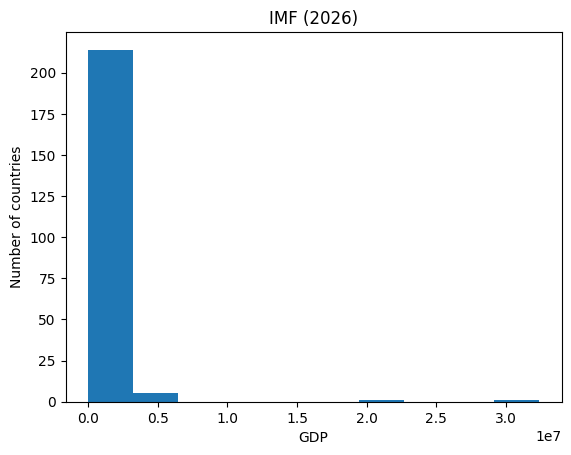

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

На гістограмі можна побачити, що розподіл показників ВВП має різко виражену правобічну асиметрію. Переважна більшість країн зосереджена в діапазоні найнижчих значень ВВП (до $0.3 \times 10^7$ млн дол.). Водночас спостерігаються явні викиди: дві країни суттєво відриваються від загальної маси — одна в районі $2.0 \times 10^7$ (Китай), а інша перевищує $3.0 \times 10^7$ (США), що свідчить про колосальну концентрацію світового ВВП серед лідерів світової економіки.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['ООН (2024)'] / df['ООН (2024)'].sum()
df.head(10)

,Country,IMF (2026),World Bank (2025),ООН (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.246549,0.250349,0.252696
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.158750,0.158640,0.161666
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.041514,0.041095,0.040192
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.033341,0.036085,0.034726
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.032469,0.032566,0.031791
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.031620,0.032187,0.034088
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.027378,0.027389,0.027259
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020847,0.020760,0.020535
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.020224,0.020839,0.018745
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020068,0.018550,0.018853


Загалом частки країн у світовому ВВП залишаються досить стабільними, а будь-які коливання є мінімальними та не перевищують десятих часток відсотка.
У США спостерігається поступове зменшення частки у світовому ВВП — з 25.27% у 2024 році (ООН) до 25.03% у 2025 році (Світовий банк) та до 24.65% у 2026 році (МВФ). Схожа тенденція до незначного зменшення частки спостерігається і в Китаю — з 16.17% до 15.88%.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

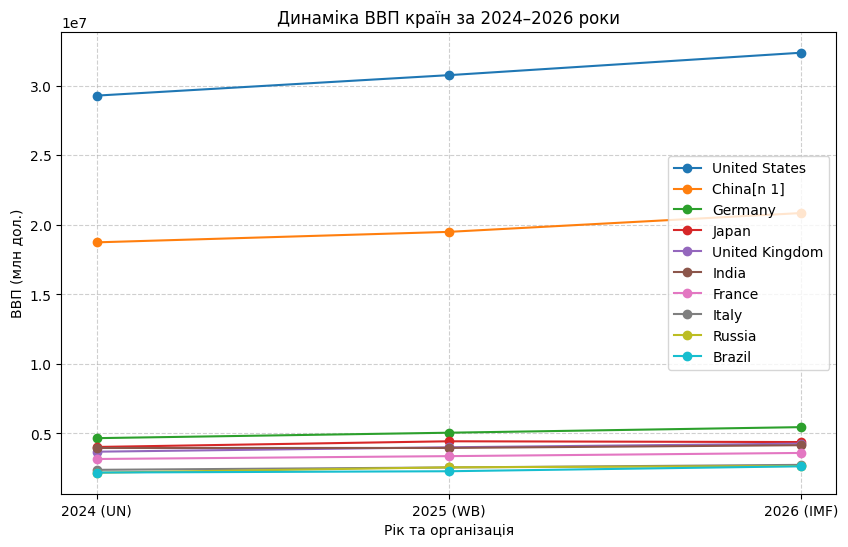

Кількість країн зі стабільним зростанням: 170
Приклади країн зі зростанням: ['United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India']

Кількість країн зі стабільним спадом: 3
Країни зі спадом: ['Iran', 'Ethiopia', 'Yemen']


In [ ]:
years = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']
cols = ['ООН (2024)', 'World Bank (2025)', 'IMF (2026)']
plt.figure(figsize=(10, 6))
for idx, row in df.head(10).iterrows():
    plt.plot(years, row[cols], marker='o', label=row['Country'])
plt.title('Динаміка ВВП країн за 2024–2026 роки')
plt.xlabel('Рік та організація')
plt.ylabel('ВВП (млн дол.)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
growth_mask = (df[cols[0]] < df[cols[1]]) & (df[cols[1]] < df[cols[2]])
decline_mask = (df[cols[0]] > df[cols[1]]) & (df[cols[1]] > df[cols[2]])
stable_growth = df[growth_mask]['Country'].tolist()
stable_decline = df[decline_mask]['Country'].tolist()
print(f"Кількість країн зі стабільним зростанням: {len(stable_growth)}")
print("Приклади країн зі зростанням:", stable_growth[:5])
print(f"\nКількість країн зі стабільним спадом: {len(stable_decline)}")
print("Країни зі спадом:", stable_decline if stable_decline else "Немає або поодинокі")

На графіку видно, що переважна більшість країн демонструють стабільне зростання абсолютних показників ВВП від 2024 до 2026 року. Водночас стабільний спад майже не спостерігається і притаманний лише окремим економікам із нестабільною фінансовою чи геополітичною ситуацією.
Топ 5 країн за зростанням: США, Китай, Німеччина, Велика Британія, Індія.
Країни зі стабільним спадом: Іран, Ефіопія, Йемен.